imports

In [5]:
import pickle
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib
import powerlaw

In [6]:
with open('letterboxd_network.pickle', 'rb') as f:
    G = pickle.load(f)

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

Nodes: 641
Edges: 18841


In [7]:
# Graph für Layout vorbereiten (undirected für bessere Visualisierung)
GUndirected = G.to_undirected()

# Node masses und sizes für besseres Layout
degrees = dict(GUndirected.degree())
node_mass = {node: degrees[node] + 1 for node in GUndirected.nodes()}
node_radius = {node: degrees[node] * 0.5 for node in GUndirected.nodes()}

# ForceAtlas2 Layout berechnen mit NetworkX
print("Berechne ForceAtlas2 Layout...")
positions = nx.forceatlas2_layout(
    GUndirected,
    max_iter=1200,
    jitter_tolerance=0.25,
    scaling_ratio=8.0,
    gravity=2.0,
    strong_gravity=False,
    linlog=True,
    node_mass=node_mass,
    node_size=node_radius,
    seed=42
)
print("Layout fertig!")

Berechne ForceAtlas2 Layout...


/opt/miniconda3/lib/python3.13/site-packages/networkx/drawing/layout.py:1809: RuntimeWarning: invalid value encountered in divide
  attraction = -np.log(1 + distance) / distance


Layout fertig!


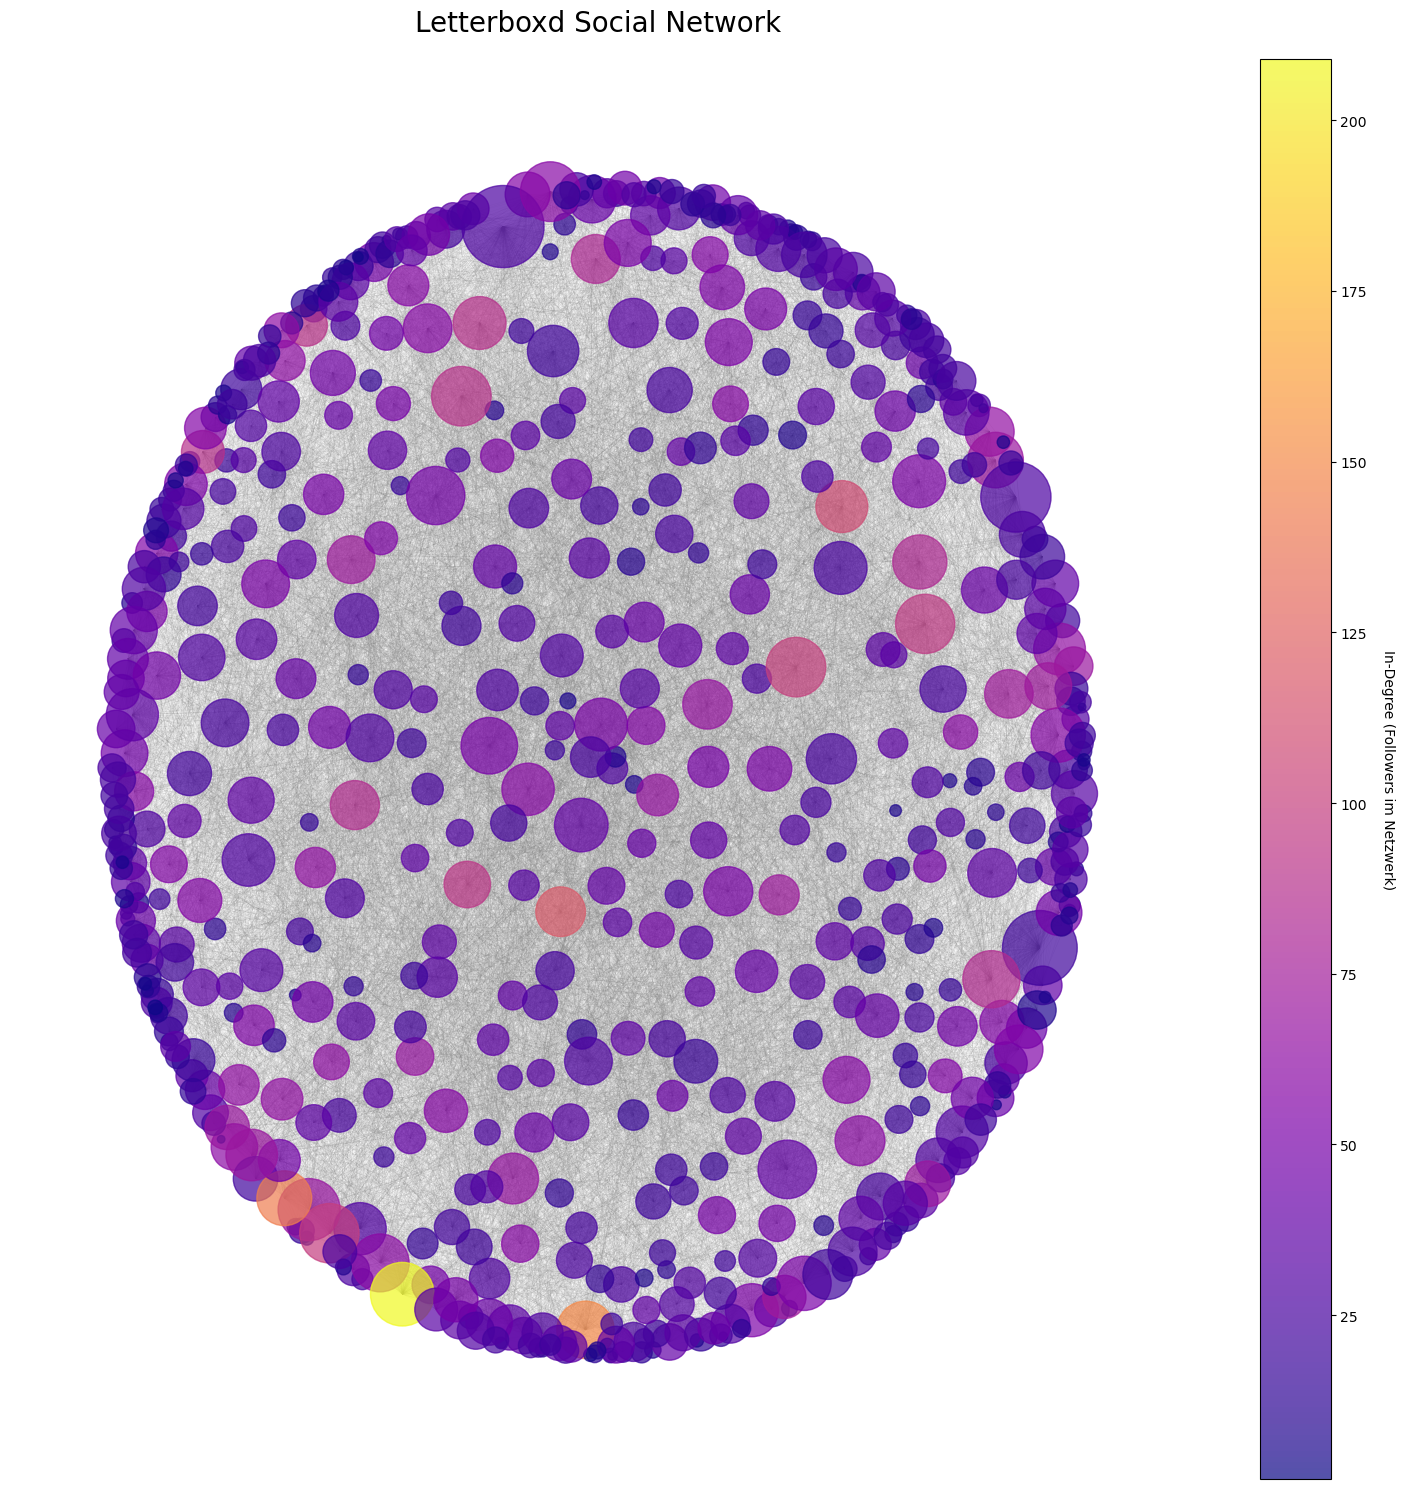

In [8]:
# Visualisierung erstellen
fig, ax = plt.subplots(figsize=(15, 15))

# Node-Größen basierend auf Degree
degrees = dict(G.degree())
node_sizes = [degrees[node] * 10 for node in G.nodes()]

# Node-Farben basierend auf In-Degree
in_degrees = dict(G.in_degree())
node_colors = [in_degrees[node] for node in G.nodes()]

# Edges zeichnen
nx.draw_networkx_edges(
    G, positions, 
    alpha=0.1, 
    width=0.3,
    edge_color='gray',
    arrows=False,
    ax=ax
)

# Nodes zeichnen
nodes = nx.draw_networkx_nodes(
    G, positions,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.plasma,
    alpha=0.7,
    ax=ax
)

# Colorbar
cbar = plt.colorbar(nodes, ax=ax)
cbar.set_label('In-Degree (Followers im Netzwerk)', rotation=270, labelpad=20)

ax.set_title('Letterboxd Social Network', fontsize=20, pad=20)
ax.axis('off')
plt.tight_layout()
plt.show()

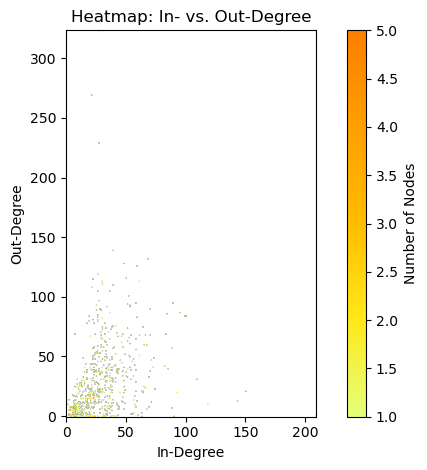

In [9]:
nodes = list(G.nodes())
in_deg  = dict(G.in_degree())
out_deg = dict(G.out_degree())

x = np.array([in_deg[n]  for n in nodes])
y = np.array([out_deg[n]  for n in nodes])

bins = (np.arange(x.max() + 2) - 0.5, np.arange(y.max() + 2) - 0.5)

heatmap, xedges, yedges = np.histogram2d(x, y, bins=bins)
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

plt.clf()
H = np.ma.masked_equal(heatmap.T, 0)
plt.imshow(H, extent=extent, origin='lower', cmap='Wistia')
plt.xlabel("In-Degree")
plt.ylabel("Out-Degree")
plt.title("Heatmap: In- vs. Out-Degree")
plt.colorbar(label="Number of Nodes")
plt.tight_layout()
plt.show()

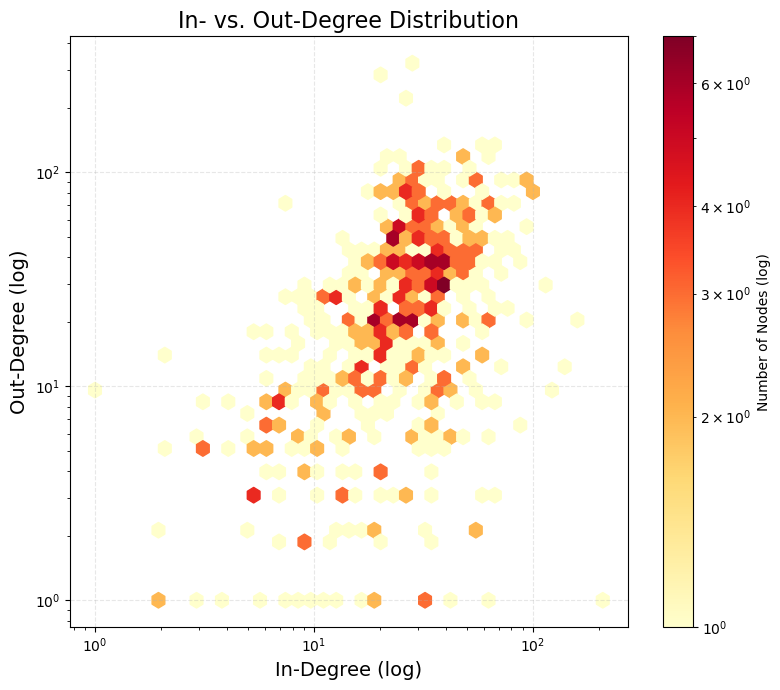

Nodes mit degree > 0: 599/641
Durchschnitt In-Degree: 29.87
Durchschnitt Out-Degree: 31.45
Max In-Degree: 209
Max Out-Degree: 323


In [10]:
# Daten sammeln (nur Nodes mit degree > 0)
in_degrees = [G.in_degree(node) for node in G.nodes()]
out_degrees = [G.out_degree(node) for node in G.nodes()]

# Filter: Nur Nodes mit beiden Degrees > 0
valid_pairs = [(i, o) for i, o in zip(in_degrees, out_degrees) if i > 0 and o > 0]
in_deg_filtered = [p[0] for p in valid_pairs]
out_deg_filtered = [p[1] for p in valid_pairs]

# Visualisierung
fig, ax = plt.subplots(figsize=(8, 7))

hb = plt.hexbin(in_deg_filtered, out_deg_filtered,
              gridsize=40,
              cmap='YlOrRd',
              mincnt=1,
              xscale='log',
              yscale='log',
              bins='log')

plt.xlabel('In-Degree (log)', fontsize=14)
plt.ylabel('Out-Degree (log)', fontsize=14)
plt.title('In- vs. Out-Degree Distribution', fontsize=16)
plt.colorbar(hb, label='Number of Nodes (log)')
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# Statistiken
print(f"Nodes mit degree > 0: {len(valid_pairs)}/{len(in_degrees)}")
print(f"Durchschnitt In-Degree: {np.mean(in_deg_filtered):.2f}")
print(f"Durchschnitt Out-Degree: {np.mean(out_deg_filtered):.2f}")
print(f"Max In-Degree: {max(in_deg_filtered)}")
print(f"Max Out-Degree: {max(out_deg_filtered)}")

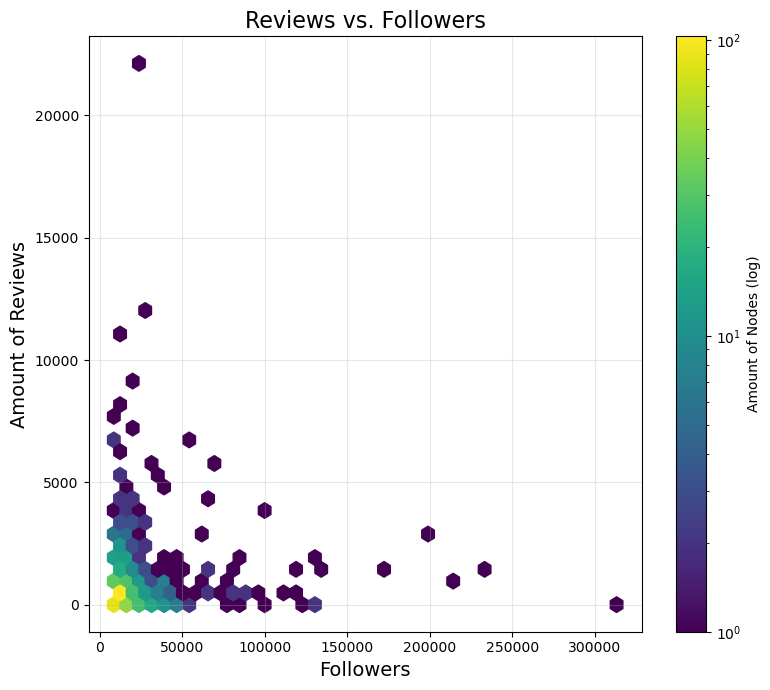

User mit Reviews: 591/641
Korrelation: 0.020


In [11]:
# Daten sammeln (nur User mit Reviews > 0)
followers = []
review_counts = []

for node in G.nodes():
  node_data = G.nodes[node]
  num_reviews = len(node_data['reviews'])

  if num_reviews > 0:  # Filter: nur User mit Reviews
      followers.append(node_data['followers_count'])
      review_counts.append(num_reviews)

# Visualisierung
fig, ax = plt.subplots(figsize=(8, 7))

plt.hexbin(followers, review_counts,
         gridsize=40,
         cmap='viridis',
         mincnt=1,
         bins='log')

plt.xlabel('Followers', fontsize=14)
plt.ylabel('Amount of Reviews', fontsize=14)
plt.title('Reviews vs. Followers', fontsize=16)
plt.colorbar(label='Amount of Nodes (log)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Korrelation
correlation = np.corrcoef(followers, review_counts)[0, 1]
print(f"User mit Reviews: {len(followers)}/{G.number_of_nodes()}")
print(f"Korrelation: {correlation:.3f}")

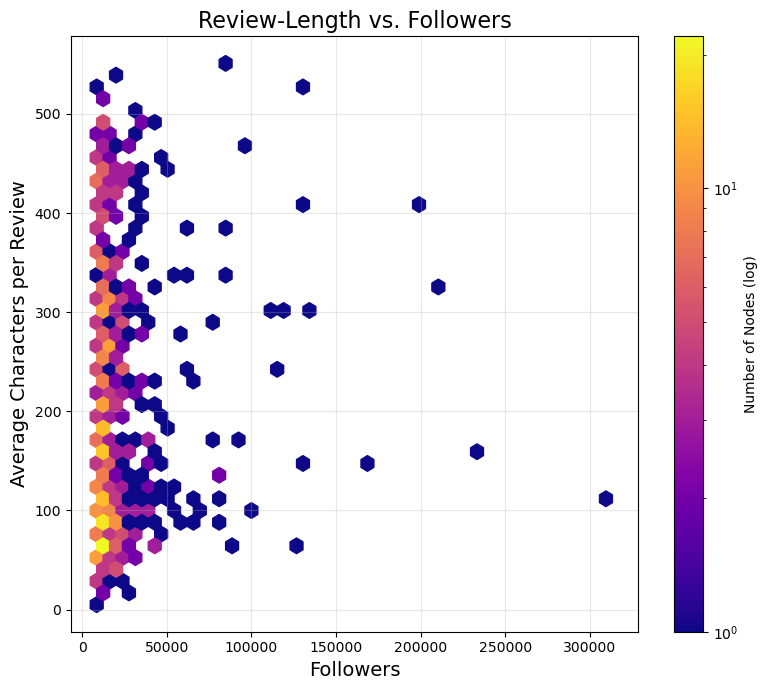

User mit Review-Text: 591/641
Korrelation: 0.035
Durchschnittliche Review-Länge: 219 Zeichen


In [12]:
# Daten sammeln (nur User mit Reviews > 0 und Länge > 0)
followers = []
avg_review_lengths = []

for node in G.nodes():
  node_data = G.nodes[node]
  reviews = node_data['reviews']

  if len(reviews) > 0:
      # Berechne durchschnittliche Länge
      review_lengths = []
      for review_id, review_data in reviews.items():
          if 'review' in review_data and review_data['review'] and 'content' in review_data['review']:
              content = review_data['review']['content']
              if content:
                  review_lengths.append(len(content))

      # Filter: nur wenn durchschnittliche Länge > 0
      if review_lengths and np.mean(review_lengths) > 0:
          followers.append(node_data['followers_count'])
          avg_review_lengths.append(np.mean(review_lengths))

# Visualisierung
fig, ax = plt.subplots(figsize=(8, 7))

plt.hexbin(followers, avg_review_lengths,
         gridsize=40,
         cmap='plasma',
         mincnt=1,
         bins='log')

plt.xlabel('Followers', fontsize=14)
plt.ylabel('Average Characters per Review', fontsize=14)
plt.title('Review-Length vs. Followers', fontsize=16)
plt.colorbar(label='Number of Nodes (log)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Korrelation
correlation = np.corrcoef(followers, avg_review_lengths)[0, 1]
print(f"User mit Review-Text: {len(followers)}/{G.number_of_nodes()}")
print(f"Korrelation: {correlation:.3f}")
print(f"Durchschnittliche Review-Länge: {np.mean(avg_review_lengths):.0f} Zeichen")

In [13]:
total_degrees = in_degrees + out_degrees
total_degrees.sort()
in_deg_pos  = [d for d in in_degrees  if d > 0]
out_deg_pos = [d for d in out_degrees if d > 0]
tot_deg_pos = [d for d in total_degrees if d > 0]


print("Degree Exponent:\n")
print(f"In-Degree:\t{powerlaw.Fit(in_deg_pos).alpha}")
print(f"Out-Degree:\t{powerlaw.Fit(out_deg_pos).alpha}")
print(f"Total-Degree:\t{powerlaw.Fit(tot_deg_pos).alpha}")

Degree Exponent:

In-Degree:	4.82094342016144
Out-Degree:	4.704868662703671
Total-Degree:	4.870616411832755


Calculating best minimal value for power law fit
/opt/miniconda3/lib/python3.13/site-packages/powerlaw.py:699: RuntimeWarning: invalid value encountered in divide
  (CDF_diff**2) /
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit


Followers - Min: 0, Max: 449436, Unique: 621
In-Degrees - Min: 1, Max: 209, Unique: 89
Total nodes: 641

After filtering zeros: 634 nodes


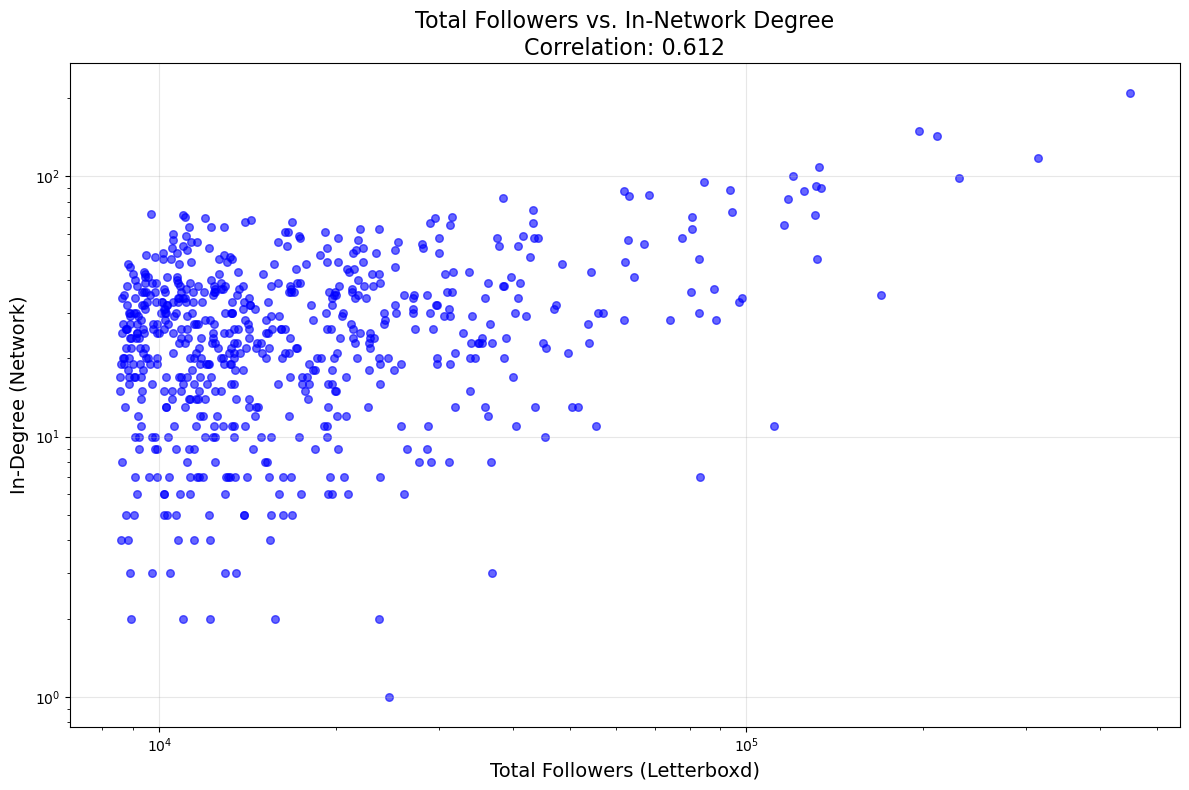


Correlation: 0.6122


In [14]:
# Debug and plot correlation
import numpy as np
import matplotlib.pyplot as plt

# Collect data
followers = [G.nodes[node]['followers_count'] for node in G.nodes()]
in_degrees = [G.in_degree(node) for node in G.nodes()]

# Check data
print(f"Followers - Min: {min(followers)}, Max: {max(followers)}, Unique: {len(set(followers))}")
print(f"In-Degrees - Min: {min(in_degrees)}, Max: {max(in_degrees)}, Unique: {len(set(in_degrees))}")
print(f"Total nodes: {len(followers)}")

# Filter out zeros for log scale
valid_pairs = [(f, d) for f, d in zip(followers, in_degrees) if f > 0 and d > 0]
followers_filtered = [p[0] for p in valid_pairs]
in_deg_filtered = [p[1] for p in valid_pairs]

print(f"\nAfter filtering zeros: {len(valid_pairs)} nodes")

# Calculate correlation
correlation = np.corrcoef(followers_filtered, in_deg_filtered)[0, 1]

# Plot with scatter (easier to see what's happening)
fig, ax = plt.subplots(figsize=(12, 8))

plt.scatter(followers_filtered, in_deg_filtered, alpha=0.6, s=30, c='blue')

plt.xlabel('Total Followers (Letterboxd)', fontsize=14)
plt.ylabel('In-Degree (Network)', fontsize=14)
plt.title(f'Total Followers vs. In-Network Degree\nCorrelation: {correlation:.3f}', fontsize=16)

plt.xscale('log')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nCorrelation: {correlation:.4f}")

In [17]:
# Convert directed graph to undirected
GUndirected = G.to_undirected()

print(f"Original directed graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Undirected graph: {GUndirected.number_of_nodes()} nodes, {GUndirected.number_of_edges()} edges\n")

# Run Louvain community detection
print("Running Louvain algorithm...\n")
communities = nx.community.louvain_communities(GUndirected, seed=42, resolution=2)

# Statistics
print(f"Number of communities detected: {len(communities)}")
print(f"\nCommunity sizes (sorted by size):")
sorted_communities = sorted(communities, key=len, reverse=True)
for i, comm in enumerate(sorted_communities, 1):
  print(f"  Community {i}: {len(comm)} nodes ({len(comm)/G.number_of_nodes()*100:.1f}%)")

# Create node-to-community mapping
node_to_community = {}
for i, comm in enumerate(communities):
  for node in comm:
      node_to_community[node] = i

# Modularity score
modularity = nx.community.modularity(GUndirected, communities)
print(f"\nModularity: {modularity:.4f}")

# Top 5 communities by total follower influence
print("\nTop 5 communities by total follower influence:")
comm_stats = []
for i, comm in enumerate(sorted_communities):
  total_followers = sum(G.nodes[node]['followers_count'] for node in comm)
  avg_followers = total_followers / len(comm)
  comm_stats.append((i+1, len(comm), total_followers, avg_followers))

for rank, (comm_id, size, total, avg) in enumerate(sorted(comm_stats, key=lambda x: x[2], reverse=True)[:5], 1):
  print(f"  {rank}. Community {comm_id}: {size} nodes, {total:,} total followers (avg: {avg:,.0f})")

Original directed graph: 641 nodes, 18841 edges
Undirected graph: 641 nodes, 15626 edges

Running Louvain algorithm...

Number of communities detected: 19

Community sizes (sorted by size):
  Community 1: 103 nodes (16.1%)
  Community 2: 68 nodes (10.6%)
  Community 3: 65 nodes (10.1%)
  Community 4: 61 nodes (9.5%)
  Community 5: 57 nodes (8.9%)
  Community 6: 55 nodes (8.6%)
  Community 7: 44 nodes (6.9%)
  Community 8: 37 nodes (5.8%)
  Community 9: 33 nodes (5.1%)
  Community 10: 20 nodes (3.1%)
  Community 11: 17 nodes (2.7%)
  Community 12: 15 nodes (2.3%)
  Community 13: 14 nodes (2.2%)
  Community 14: 13 nodes (2.0%)
  Community 15: 11 nodes (1.7%)
  Community 16: 10 nodes (1.6%)
  Community 17: 7 nodes (1.1%)
  Community 18: 6 nodes (0.9%)
  Community 19: 5 nodes (0.8%)

Modularity: 0.2837

Top 5 communities by total follower influence:
  1. Community 3: 65 nodes, 1,963,230 total followers (avg: 30,204)
  2. Community 5: 57 nodes, 1,641,934 total followers (avg: 28,806)
  3. C